# Data Sanity Check

This notebook performs initial data exploration and validation after preprocessing.

## Setup


In [1]:
import sys
from pathlib import Path

# Add src to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML

# Set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')  # Fallback for older matplotlib versions
    except OSError:
        plt.style.use('default')  # Final fallback

# Configure matplotlib for notebook display
%matplotlib inline
plt.ion()  # Turn on interactive mode

# Set pandas display options for better visibility
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

from preprocess import build_clean_dataset, save_clean_dataset
from config import Config

print("✓ All imports successful!")
print(f"✓ Python: {sys.version}")
print(f"✓ Pandas: {pd.__version__}")
print(f"✓ Matplotlib: {plt.matplotlib.__version__}")


✓ All imports successful!
✓ Python: 3.9.6 (default, Apr 30 2025, 02:07:17) 
[Clang 17.0.0 (clang-1700.0.13.5)]
✓ Pandas: 2.3.3
✓ Matplotlib: 3.9.4


## Load Raw Data

Load and inspect the raw data files before preprocessing.


In [2]:
config = Config()

# Load raw data files
print("Loading wind data...")
wind_df = pd.read_csv(config.data_raw_dir / "wind_data.csv", comment='#', parse_dates=['time'])
wind_df['time'] = pd.to_datetime(wind_df['time'], utc=True)
wind_df = wind_df.set_index('time')
wind_df['wind_kw'] = wind_df['electricity']  # Rename for clarity
wind_df = wind_df[['wind_kw']].copy()

print("Loading PV data...")
pv_df = pd.read_csv(config.data_raw_dir / "pv_data.csv", comment='#', parse_dates=['time'])
pv_df['time'] = pd.to_datetime(pv_df['time'], utc=True)
pv_df = pv_df.set_index('time')
pv_df['pv_kw'] = pv_df['electricity']  # Rename for clarity
pv_df = pv_df[['pv_kw']].copy()

print("Loading price data...")
price_df = pd.read_csv(
    config.data_raw_dir / "price_data.csv", 
    sep=';',
    parse_dates=['Start date'],
    decimal=','
)
price_df = price_df.rename(columns={
    'Start date': 'time',
    'Germany/Luxembourg [€/MWh] Calculated resolutions': 'price_eur_per_mwh'
})
price_df['time'] = pd.to_datetime(price_df['time'], utc=True)
price_df = price_df.set_index('time')
price_df = price_df[['price_eur_per_mwh']].copy()

# Convert price column to numeric, handling non-numeric values (like "-")
# Replace commas with dots if still present, then convert
price_df['price_eur_per_mwh'] = price_df['price_eur_per_mwh'].astype(str).str.replace(',', '.')
price_df['price_eur_per_mwh'] = pd.to_numeric(price_df['price_eur_per_mwh'], errors='coerce')

print(f"\n✓ Data loaded successfully!")
print(f"Wind data shape: {wind_df.shape}")
print(f"PV data shape: {pv_df.shape}")
print(f"Price data shape: {price_df.shape}")

# Display data shapes as a DataFrame for better visibility
summary_df = pd.DataFrame({
    'Dataset': ['Wind', 'PV', 'Price'],
    'Rows': [len(wind_df), len(pv_df), len(price_df)],
    'Columns': [wind_df.shape[1], pv_df.shape[1], price_df.shape[1]],
    'Start Date': [wind_df.index.min(), pv_df.index.min(), price_df.index.min()],
    'End Date': [wind_df.index.max(), pv_df.index.max(), price_df.index.max()]
})
display(summary_df)


Loading wind data...
Loading PV data...
Loading price data...


/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_7727/2172101035.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  price_df = pd.read_csv(



✓ Data loaded successfully!
Wind data shape: (8784, 1)
PV data shape: (8784, 1)
Price data shape: (8784, 1)


,Dataset,Rows,Columns,Start Date,End Date
0,Wind,8784,1,2024-01-01 00:00:00+00:00,2024-12-31 23:00:00+00:00
1,PV,8784,1,2024-01-01 00:00:00+00:00,2024-12-31 23:00:00+00:00
2,Price,8784,1,2024-01-01 00:00:00+00:00,2024-12-31 23:00:00+00:00


## 1. Wind Data Sanity Checks


In [3]:
# Basic statistics
print("=== Wind Data Overview ===")
wind_df.info()

print("\n=== Summary Statistics ===")
display(wind_df.describe())

print(f"\n=== Missing Values ===")
display(wind_df.isnull().sum())

print(f"\n=== Time Range ===")
print(f"Start: {wind_df.index.min()}")
print(f"End: {wind_df.index.max()}")
print(f"Total hours: {len(wind_df)}")
print(f"Expected hours (2024): {365 * 24}")
print(f"Missing hours: {(365 * 24) - len(wind_df)}")

# Display first few rows
print("\n=== First 5 rows ===")
display(wind_df.head())


=== Wind Data Overview ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8784 entries, 2024-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   wind_kw  8784 non-null   float64
dtypes: float64(1)
memory usage: 137.2 KB

=== Summary Statistics ===


,wind_kw
count,8784.000000
mean,0.267765
std,0.201077
min,0.000000
25%,0.114000
50%,0.227000
75%,0.367000
max,0.972000



=== Missing Values ===


wind_kw    0
dtype: int64


=== Time Range ===
Start: 2024-01-01 00:00:00+00:00
End: 2024-12-31 23:00:00+00:00
Total hours: 8784
Expected hours (2024): 8760
Missing hours: -24

=== First 5 rows ===


,wind_kw
time,
2024-01-01 00:00:00+00:00,0.274
2024-01-01 01:00:00+00:00,0.245
2024-01-01 02:00:00+00:00,0.238
2024-01-01 03:00:00+00:00,0.240
2024-01-01 04:00:00+00:00,0.249


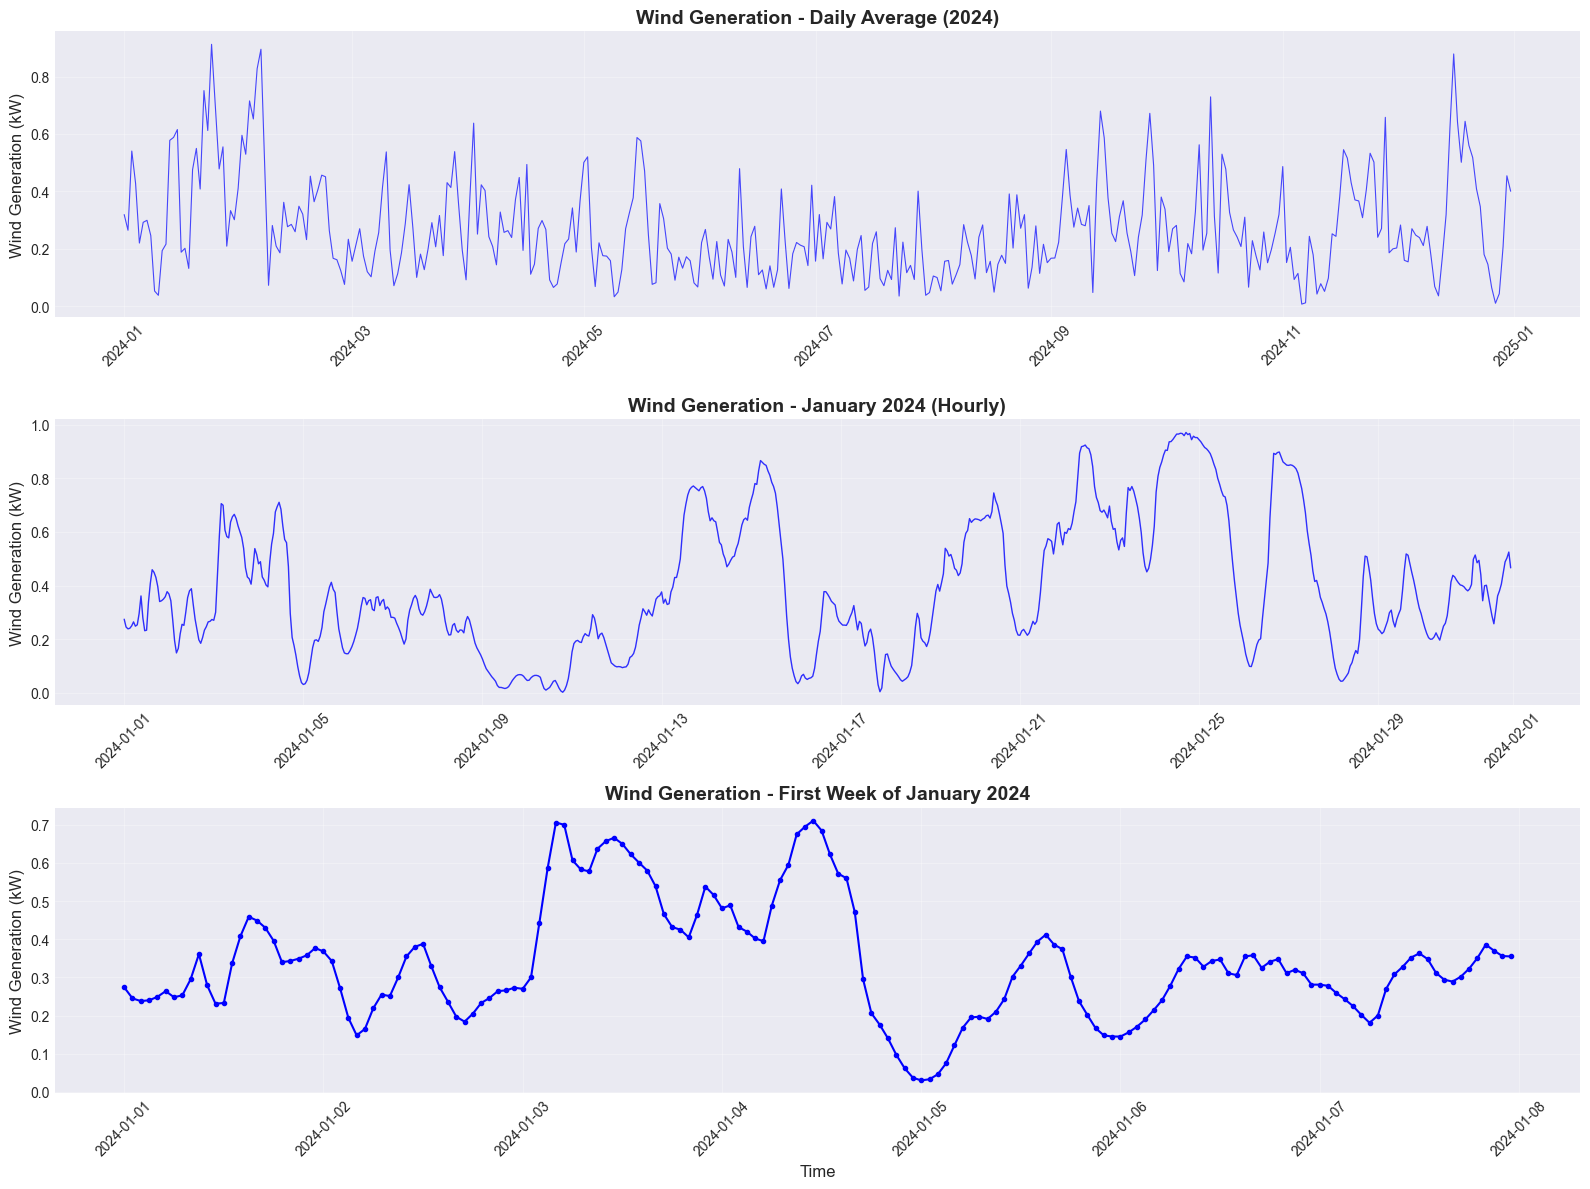

In [4]:
# Wind: Time series for sample periods
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Full year overview (daily averages)
wind_daily = wind_df['wind_kw'].resample('D').mean()
axes[0].plot(wind_daily.index, wind_daily.values, linewidth=0.8, color='blue', alpha=0.7)
axes[0].set_title('Wind Generation - Daily Average (2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Wind Generation (kW)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Sample month (January)
wind_jan = wind_df.loc['2024-01']
axes[1].plot(wind_jan.index, wind_jan['wind_kw'], linewidth=1, color='blue', alpha=0.8)
axes[1].set_title('Wind Generation - January 2024 (Hourly)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Wind Generation (kW)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Sample week
wind_week = wind_df.loc['2024-01-01':'2024-01-07']
axes[2].plot(wind_week.index, wind_week['wind_kw'], linewidth=1.5, color='blue', marker='o', markersize=3)
axes[2].set_title('Wind Generation - First Week of January 2024', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time', fontsize=12)
axes[2].set_ylabel('Wind Generation (kW)', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_7727/2612322398.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(wind_monthly, labels=month_order)


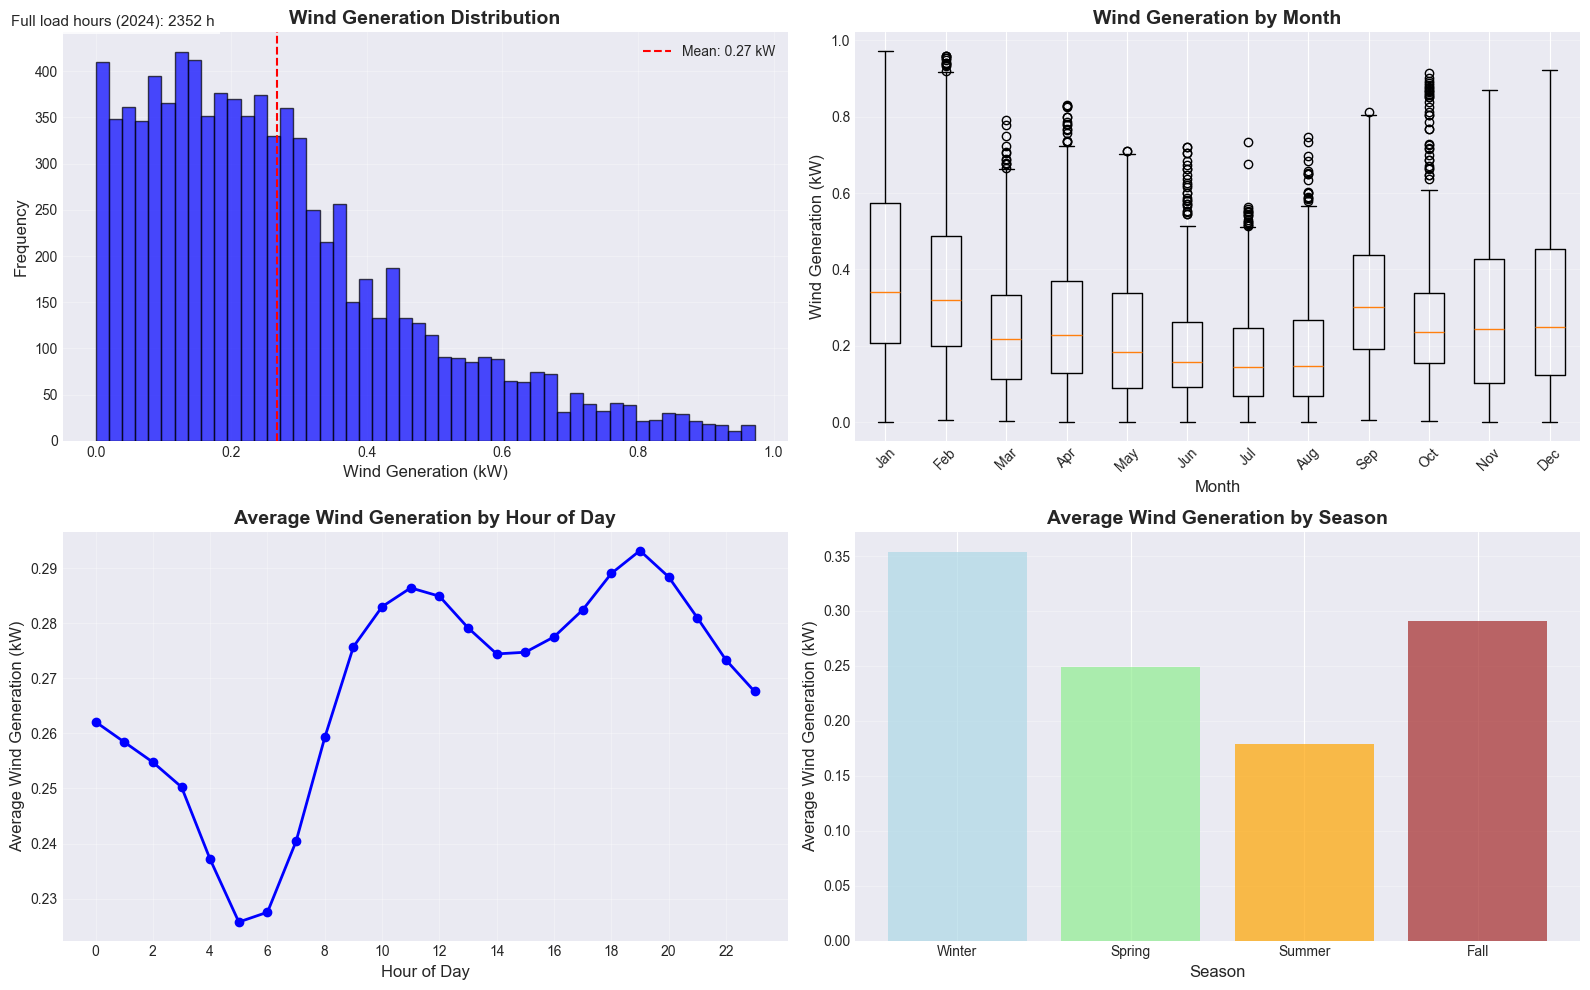

In [5]:
# Wind: Distribution and patterns

# Full load hours (1 kW capacity, hourly data)
wind_flh = wind_df['wind_kw'].sum()
flh_text = f"Full load hours (2024): {wind_flh:.0f} h"

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.text(
    0.01, 0.98, flh_text, ha='left', va='top', fontsize=11,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)


# Histogram
axes[0, 0].hist(wind_df['wind_kw'], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0, 0].set_xlabel('Wind Generation (kW)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Wind Generation Distribution', fontsize=14, fontweight='bold')
axes[0, 0].axvline(wind_df['wind_kw'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {wind_df["wind_kw"].mean():.2f} kW')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Monthly pattern (boxplot)
wind_df['month'] = wind_df.index.month
wind_df['month_name'] = wind_df.index.strftime('%b')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
wind_df['month_name'] = pd.Categorical(wind_df['month_name'], categories=month_order, ordered=True)
wind_monthly = [wind_df[wind_df['month'] == i]['wind_kw'].values for i in range(1, 13)]
axes[0, 1].boxplot(wind_monthly, labels=month_order)
axes[0, 1].set_xlabel('Month', fontsize=12)
axes[0, 1].set_ylabel('Wind Generation (kW)', fontsize=12)
axes[0, 1].set_title('Wind Generation by Month', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].tick_params(axis='x', rotation=45)

# Hourly pattern (average by hour of day)
wind_df['hour'] = wind_df.index.hour
hourly_avg = wind_df.groupby('hour')['wind_kw'].mean()
axes[1, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, markersize=6, color='blue')
axes[1, 0].set_xlabel('Hour of Day', fontsize=12)
axes[1, 0].set_ylabel('Average Wind Generation (kW)', fontsize=12)
axes[1, 0].set_title('Average Wind Generation by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3)

# Seasonal pattern
wind_df['season'] = wind_df.index.month.map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                              3: 'Spring', 4: 'Spring', 5: 'Spring',
                                              6: 'Summer', 7: 'Summer', 8: 'Summer',
                                              9: 'Fall', 10: 'Fall', 11: 'Fall'})
seasonal_avg = wind_df.groupby('season')['wind_kw'].mean()
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_avg = seasonal_avg.reindex(season_order)
axes[1, 1].bar(seasonal_avg.index, seasonal_avg.values, color=['lightblue', 'lightgreen', 'orange', 'brown'], alpha=0.7)
axes[1, 1].set_xlabel('Season', fontsize=12)
axes[1, 1].set_ylabel('Average Wind Generation (kW)', fontsize=12)
axes[1, 1].set_title('Average Wind Generation by Season', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 2. PV Data Sanity Checks


In [6]:
# Basic statistics
print("=== PV Data Overview ===")
print(pv_df.info())
print("\n=== Summary Statistics ===")
print(pv_df.describe())
print(f"\n=== Missing Values ===")
print(pv_df.isnull().sum())
print(f"\n=== Time Range ===")
print(f"Start: {pv_df.index.min()}")
print(f"End: {pv_df.index.max()}")
print(f"Total hours: {len(pv_df)}")
print(f"Expected hours (2024): {365 * 24}")
print(f"Missing hours: {(365 * 24) - len(pv_df)}")


=== PV Data Overview ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8784 entries, 2024-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pv_kw   8784 non-null   float64
dtypes: float64(1)
memory usage: 137.2 KB
None

=== Summary Statistics ===
             pv_kw
count  8784.000000
mean      0.132253
std       0.211945
min       0.000000
25%       0.000000
50%       0.000000
75%       0.194000
max       0.811000

=== Missing Values ===
pv_kw    0
dtype: int64

=== Time Range ===
Start: 2024-01-01 00:00:00+00:00
End: 2024-12-31 23:00:00+00:00
Total hours: 8784
Expected hours (2024): 8760
Missing hours: -24


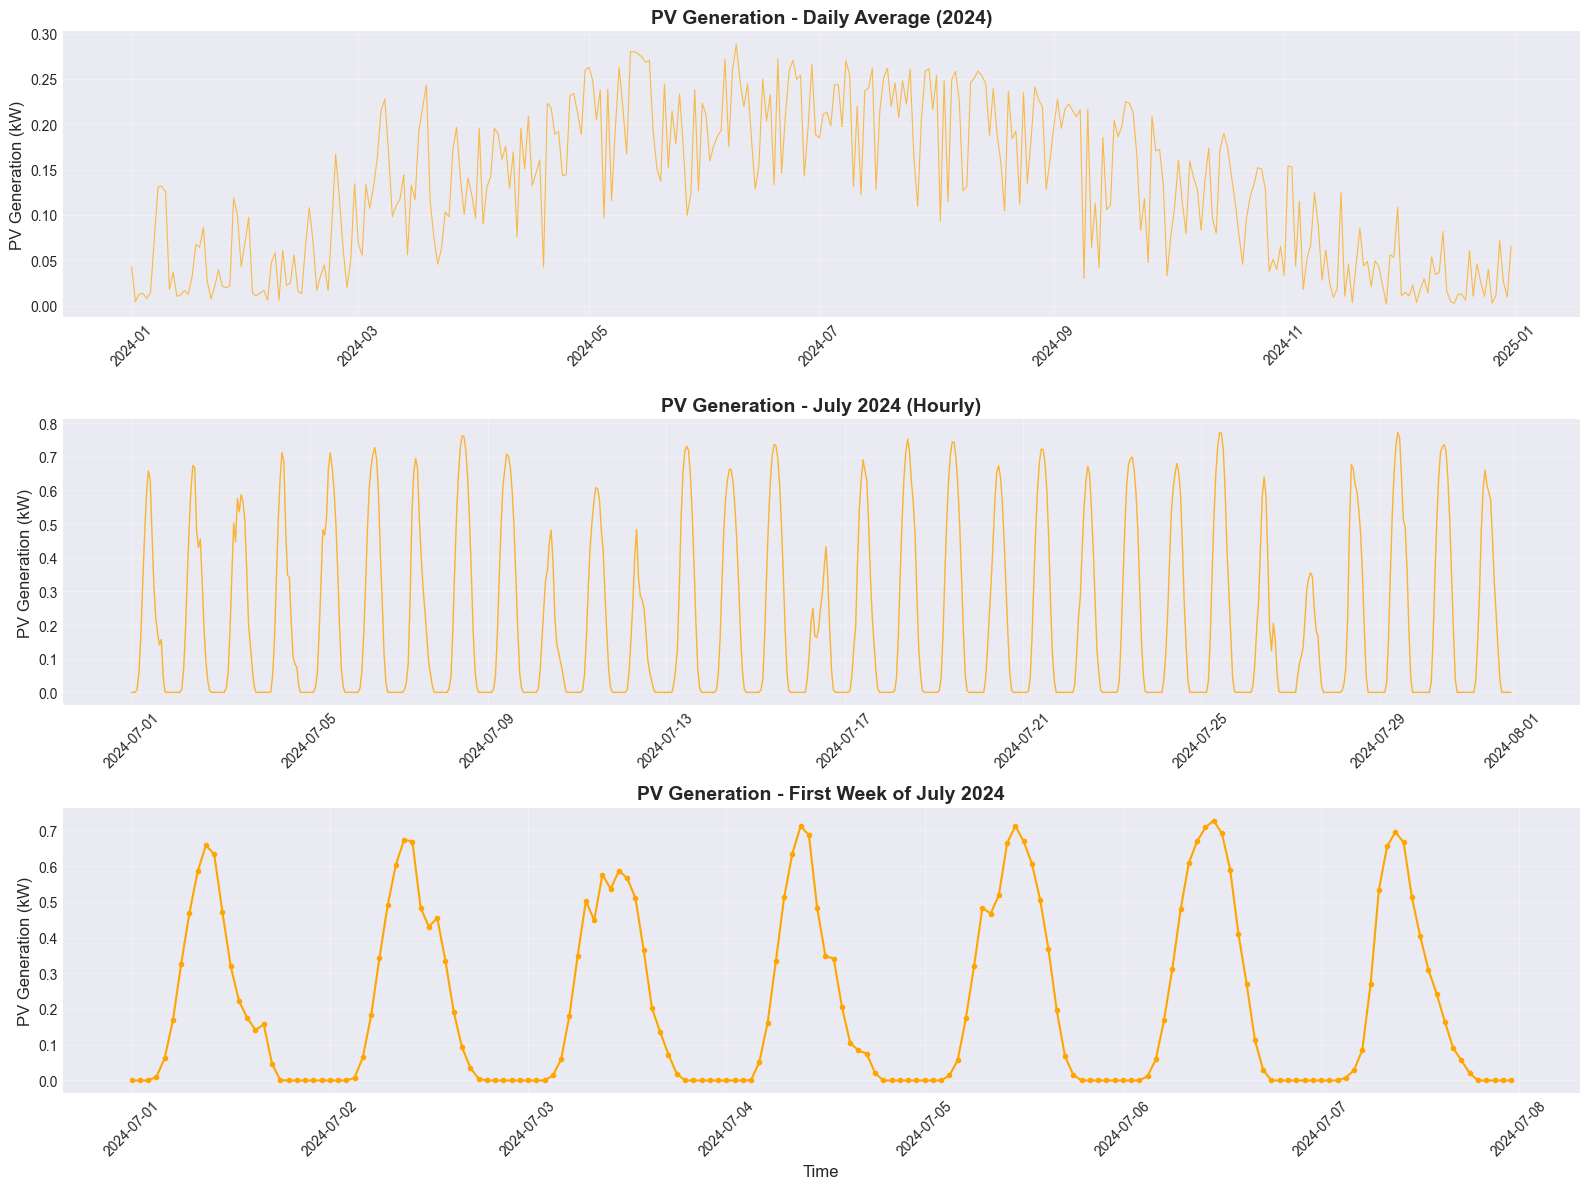

In [7]:
# PV: Time series for sample periods
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Full year overview (daily averages)
pv_daily = pv_df['pv_kw'].resample('D').mean()
axes[0].plot(pv_daily.index, pv_daily.values, linewidth=0.8, color='orange', alpha=0.7)
axes[0].set_title('PV Generation - Daily Average (2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('PV Generation (kW)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Sample month (July - peak summer)
pv_jul = pv_df.loc['2024-07']
axes[1].plot(pv_jul.index, pv_jul['pv_kw'], linewidth=1, color='orange', alpha=0.8)
axes[1].set_title('PV Generation - July 2024 (Hourly)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('PV Generation (kW)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Sample week
pv_week = pv_df.loc['2024-07-01':'2024-07-07']
axes[2].plot(pv_week.index, pv_week['pv_kw'], linewidth=1.5, color='orange', marker='o', markersize=3)
axes[2].set_title('PV Generation - First Week of July 2024', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time', fontsize=12)
axes[2].set_ylabel('PV Generation (kW)', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_7727/814241826.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(pv_monthly, labels=month_order)


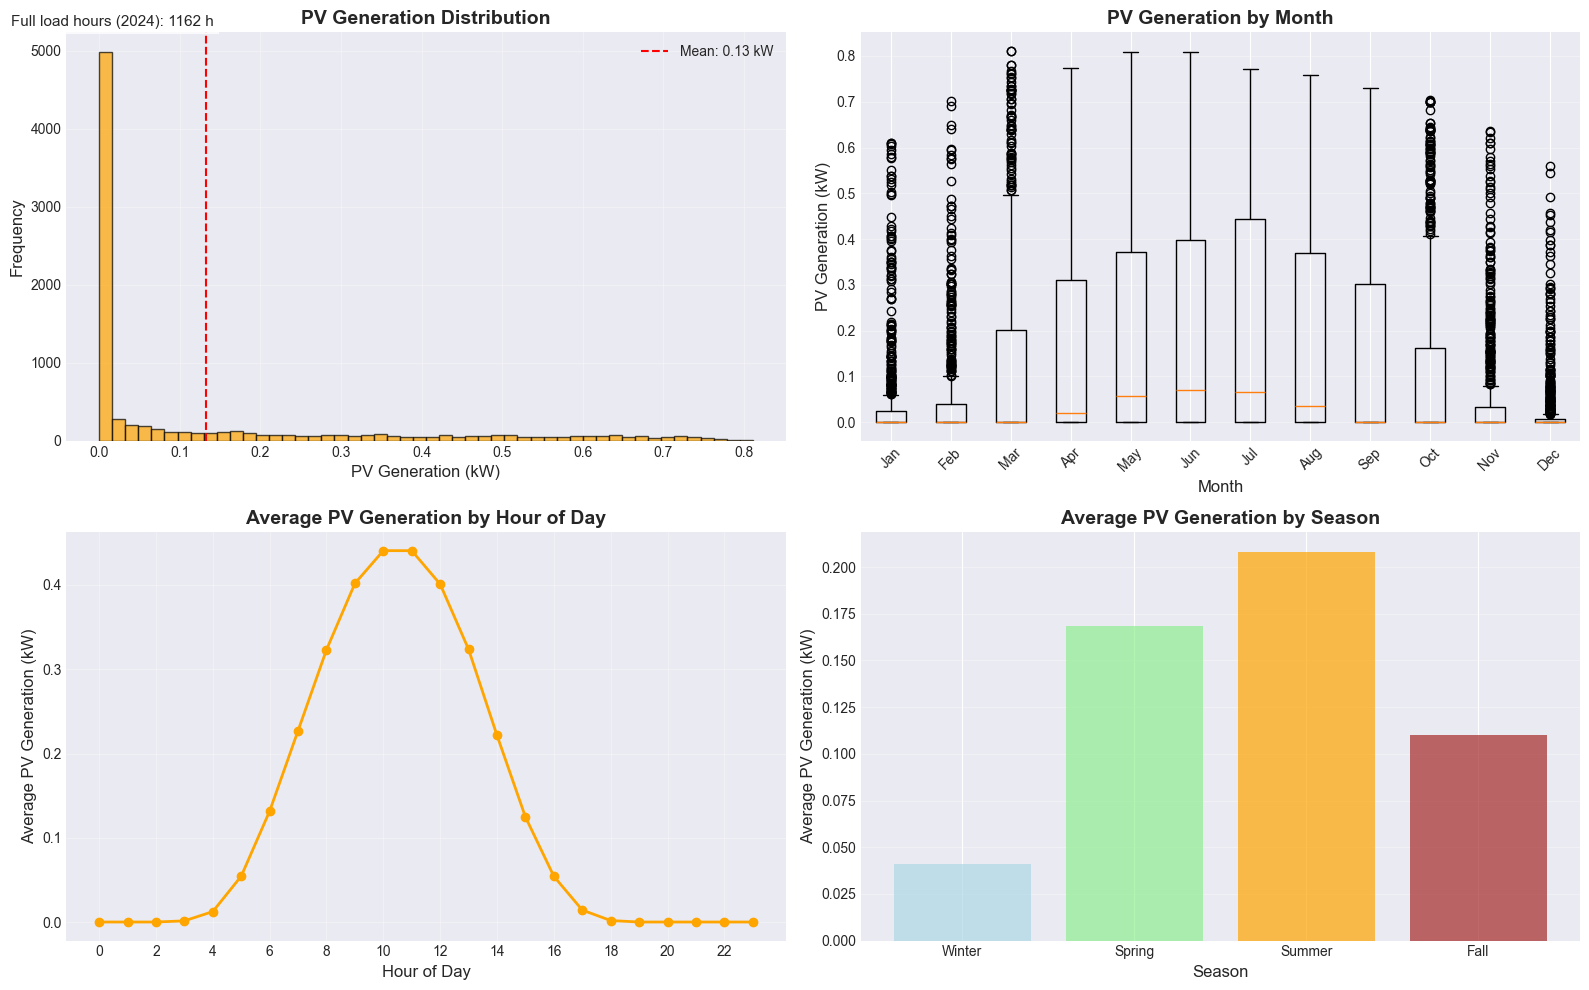

In [8]:
# PV: Distribution and patterns

# Full load hours (1 kW capacity, hourly data)
pv_flh = pv_df['pv_kw'].sum()
flh_text = f"Full load hours (2024): {pv_flh:.0f} h"

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.text(
    0.01, 0.98, flh_text, ha='left', va='top', fontsize=11,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)


# Histogram
axes[0, 0].hist(pv_df['pv_kw'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 0].set_xlabel('PV Generation (kW)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('PV Generation Distribution', fontsize=14, fontweight='bold')
axes[0, 0].axvline(pv_df['pv_kw'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {pv_df["pv_kw"].mean():.2f} kW')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Monthly pattern (boxplot)
pv_df['month'] = pv_df.index.month
pv_df['month_name'] = pv_df.index.strftime('%b')
pv_df['month_name'] = pd.Categorical(pv_df['month_name'], categories=month_order, ordered=True)
pv_monthly = [pv_df[pv_df['month'] == i]['pv_kw'].values for i in range(1, 13)]
axes[0, 1].boxplot(pv_monthly, labels=month_order)
axes[0, 1].set_xlabel('Month', fontsize=12)
axes[0, 1].set_ylabel('PV Generation (kW)', fontsize=12)
axes[0, 1].set_title('PV Generation by Month', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].tick_params(axis='x', rotation=45)

# Hourly pattern (average by hour of day) - PV should show clear diurnal pattern
pv_df['hour'] = pv_df.index.hour
hourly_avg = pv_df.groupby('hour')['pv_kw'].mean()
axes[1, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, markersize=6, color='orange')
axes[1, 0].set_xlabel('Hour of Day', fontsize=12)
axes[1, 0].set_ylabel('Average PV Generation (kW)', fontsize=12)
axes[1, 0].set_title('Average PV Generation by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3)

# Seasonal pattern
pv_df['season'] = pv_df.index.month.map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                          3: 'Spring', 4: 'Spring', 5: 'Spring',
                                          6: 'Summer', 7: 'Summer', 8: 'Summer',
                                          9: 'Fall', 10: 'Fall', 11: 'Fall'})
seasonal_avg = pv_df.groupby('season')['pv_kw'].mean()
seasonal_avg = seasonal_avg.reindex(season_order)
axes[1, 1].bar(seasonal_avg.index, seasonal_avg.values, color=['lightblue', 'lightgreen', 'orange', 'brown'], alpha=0.7)
axes[1, 1].set_xlabel('Season', fontsize=12)
axes[1, 1].set_ylabel('Average PV Generation (kW)', fontsize=12)
axes[1, 1].set_title('Average PV Generation by Season', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 3. Price Data Sanity Checks


In [9]:
# Basic statistics
print("=== Price Data Overview ===")
print(price_df.info())
print("\n=== Summary Statistics ===")
print(price_df.describe())

# Compact summary table for copy/paste
price_summary = pd.DataFrame({
    'Statistic': ['Mean', 'Min', 'Max', 'Std Dev'],
    'Value (EUR/MWh)': [
        price_df['price_eur_per_mwh'].mean(),
        price_df['price_eur_per_mwh'].min(),
        price_df['price_eur_per_mwh'].max(),
        price_df['price_eur_per_mwh'].std()
    ]
})
price_summary['Value (EUR/MWh)'] = price_summary['Value (EUR/MWh)'].map(lambda x: f"{x:.2f}")
display(price_summary)
print(f"\n=== Missing Values ===")
print(price_df.isnull().sum())
print(f"\n=== Time Range ===")
print(f"Start: {price_df.index.min()}")
print(f"End: {price_df.index.max()}")
print(f"Total hours: {len(price_df)}")

# Check for negative prices (can occur in electricity markets)
negative_prices = (price_df['price_eur_per_mwh'] < 0).sum()
print(f"\nNegative prices: {negative_prices} ({negative_prices/len(price_df)*100:.2f}%)")
print(f"Min price: {price_df['price_eur_per_mwh'].min():.2f} EUR/MWh")
print(f"Max price: {price_df['price_eur_per_mwh'].max():.2f} EUR/MWh")


=== Price Data Overview ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8784 entries, 2024-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price_eur_per_mwh  8784 non-null   float64
dtypes: float64(1)
memory usage: 137.2 KB
None

=== Summary Statistics ===
       price_eur_per_mwh
count        8784.000000
mean           78.512033
std            52.726409
min          -135.450000
25%            55.560000
50%            79.585000
75%           101.340000
max           936.280000


,Statistic,Value (EUR/MWh)
0,Mean,78.51
1,Min,-135.45
2,Max,936.28
3,Std Dev,52.73



=== Missing Values ===
price_eur_per_mwh    0
dtype: int64

=== Time Range ===
Start: 2024-01-01 00:00:00+00:00
End: 2024-12-31 23:00:00+00:00
Total hours: 8784

Negative prices: 457 (5.20%)
Min price: -135.45 EUR/MWh
Max price: 936.28 EUR/MWh


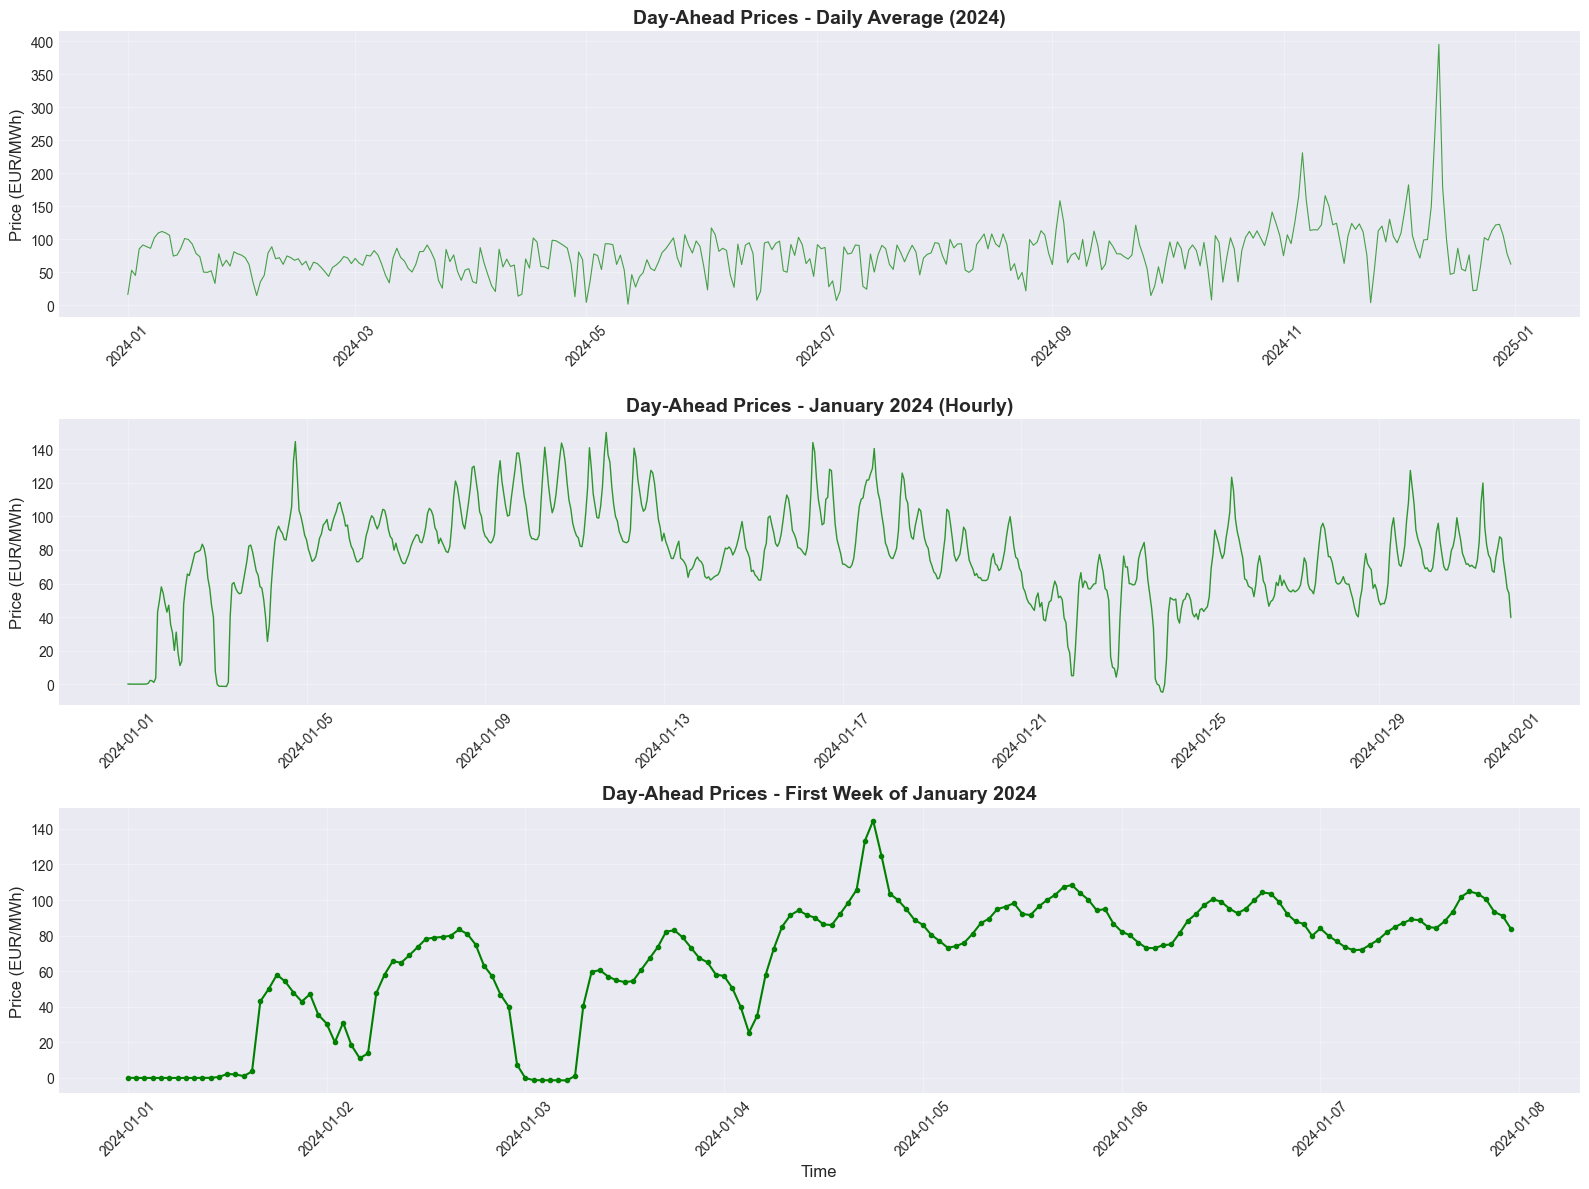

In [10]:
# Price: Time series for sample periods
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Full year overview (daily averages)
price_daily = price_df['price_eur_per_mwh'].resample('D').mean()
axes[0].plot(price_daily.index, price_daily.values, linewidth=0.8, color='green', alpha=0.7)
axes[0].set_title('Day-Ahead Prices - Daily Average (2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (EUR/MWh)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Sample month
price_month = price_df.loc['2024-01']
axes[1].plot(price_month.index, price_month['price_eur_per_mwh'], linewidth=1, color='green', alpha=0.8)
axes[1].set_title('Day-Ahead Prices - January 2024 (Hourly)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price (EUR/MWh)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Sample week
price_week = price_df.loc['2024-01-01':'2024-01-07']
axes[2].plot(price_week.index, price_week['price_eur_per_mwh'], linewidth=1.5, color='green', marker='o', markersize=3)
axes[2].set_title('Day-Ahead Prices - First Week of January 2024', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time', fontsize=12)
axes[2].set_ylabel('Price (EUR/MWh)', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_7727/1888619590.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(price_monthly, labels=month_order)


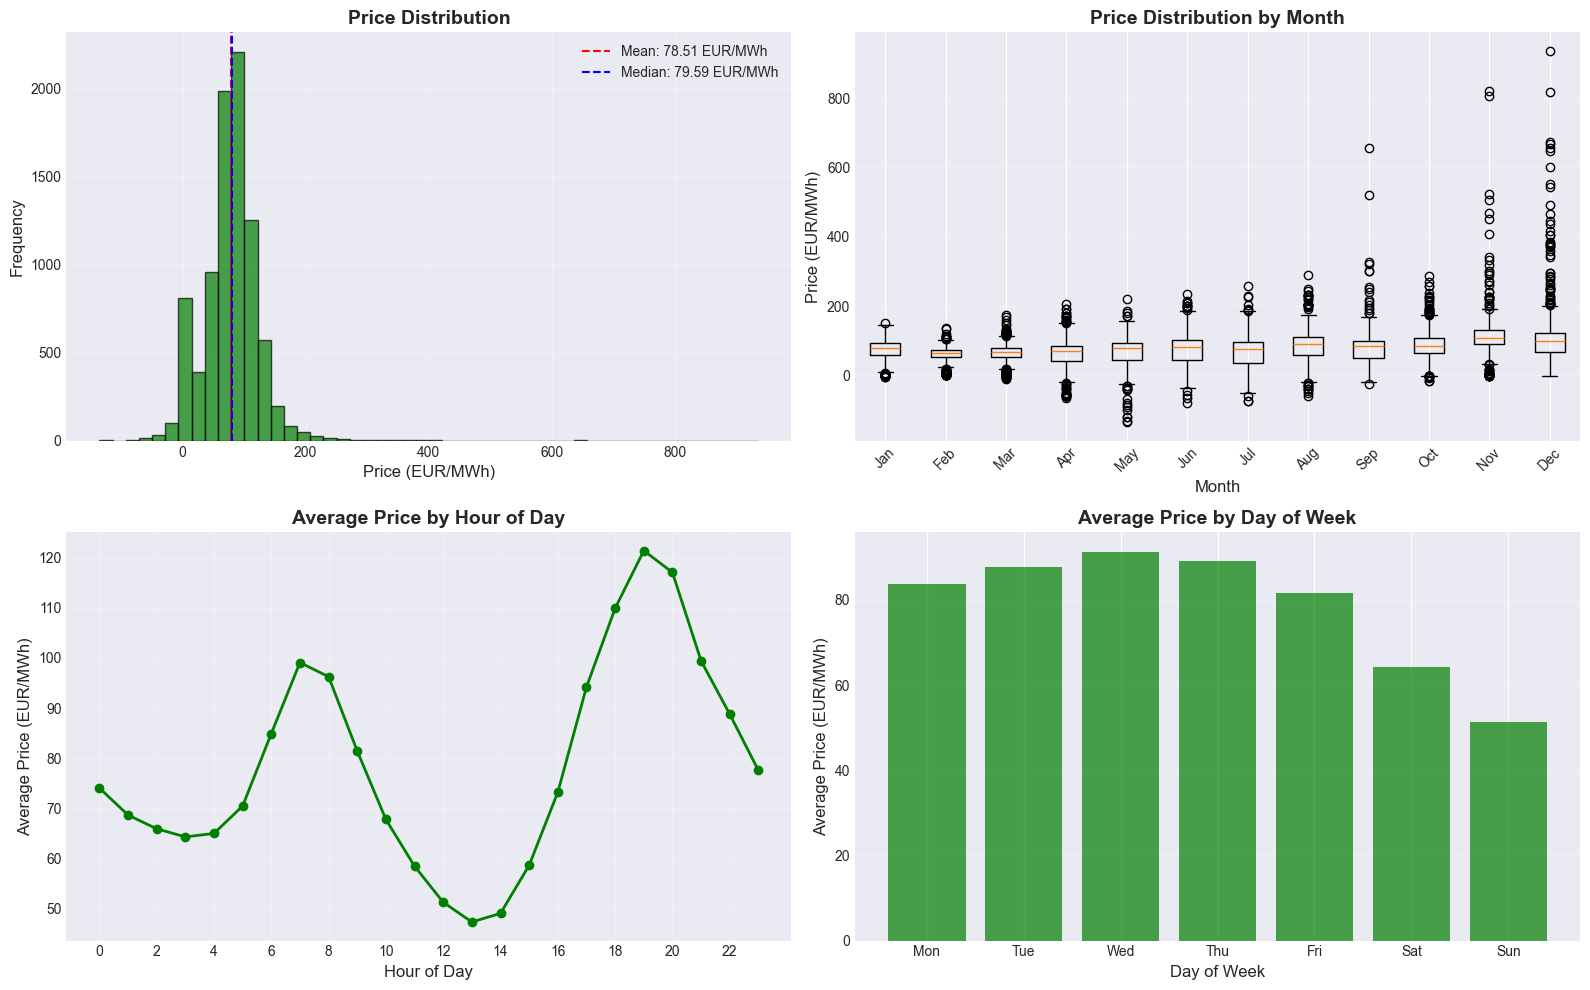

In [11]:
# Price: Distribution and patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Histogram
axes[0, 0].hist(price_df['price_eur_per_mwh'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 0].set_xlabel('Price (EUR/MWh)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0, 0].axvline(price_df['price_eur_per_mwh'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {price_df["price_eur_per_mwh"].mean():.2f} EUR/MWh')
axes[0, 0].axvline(price_df['price_eur_per_mwh'].median(), color='blue', linestyle='--', 
                   label=f'Median: {price_df["price_eur_per_mwh"].median():.2f} EUR/MWh')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Monthly pattern (boxplot)
price_df['month'] = price_df.index.month
price_df['month_name'] = price_df.index.strftime('%b')
price_df['month_name'] = pd.Categorical(price_df['month_name'], categories=month_order, ordered=True)
price_monthly = [price_df[price_df['month'] == i]['price_eur_per_mwh'].values for i in range(1, 13)]
axes[0, 1].boxplot(price_monthly, labels=month_order)
axes[0, 1].set_xlabel('Month', fontsize=12)
axes[0, 1].set_ylabel('Price (EUR/MWh)', fontsize=12)
axes[0, 1].set_title('Price Distribution by Month', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].tick_params(axis='x', rotation=45)

# Hourly pattern (average by hour of day)
price_df['hour'] = price_df.index.hour
hourly_avg = price_df.groupby('hour')['price_eur_per_mwh'].mean()
axes[1, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, markersize=6, color='green')
axes[1, 0].set_xlabel('Hour of Day', fontsize=12)
axes[1, 0].set_ylabel('Average Price (EUR/MWh)', fontsize=12)
axes[1, 0].set_title('Average Price by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3)

# Weekly pattern (average by day of week)
price_df['day_of_week'] = price_df.index.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_avg = price_df.groupby('day_of_week')['price_eur_per_mwh'].mean()
axes[1, 1].bar(range(7), daily_avg.values, color='green', alpha=0.7)
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(day_names)
axes[1, 1].set_xlabel('Day of Week', fontsize=12)
axes[1, 1].set_ylabel('Average Price (EUR/MWh)', fontsize=12)
axes[1, 1].set_title('Average Price by Day of Week', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 4. Combined Comparison


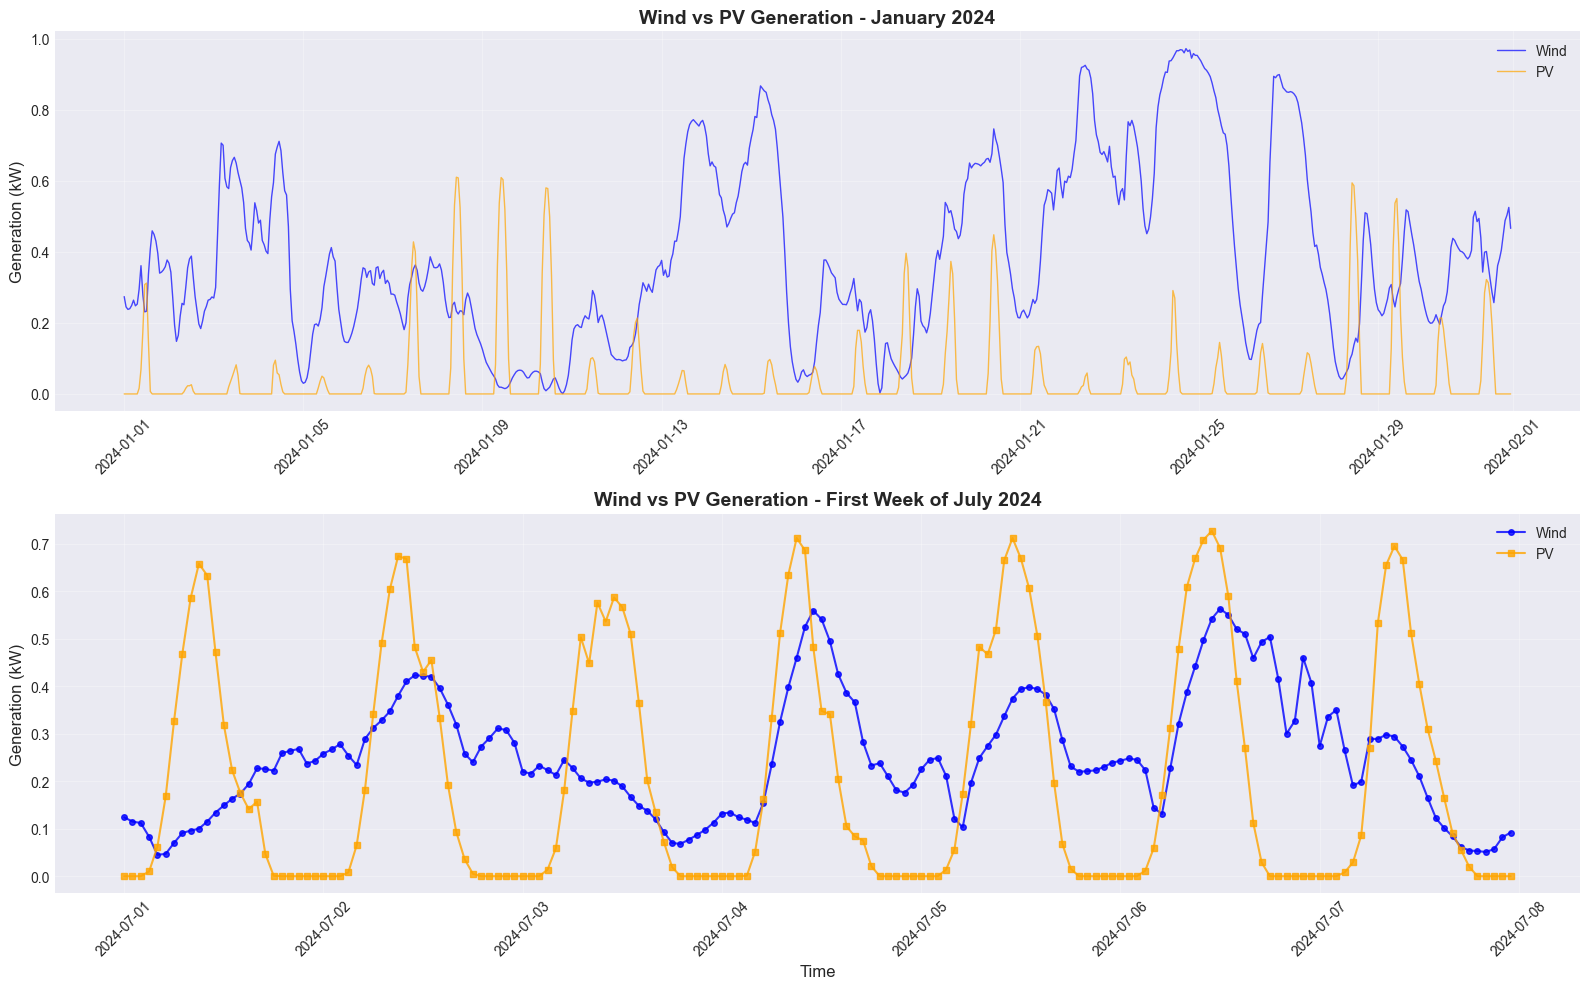

In [12]:
# Compare wind and PV generation patterns
# Note: Wind and PV data are from 2024, prices are from 2023
# This is just for visualization - actual analysis will need aligned data

# Normalize to capacity factor for comparison (assuming 1 kW capacity from Renewables.ninja)
wind_cf = wind_df['wind_kw'] / 1.0  # Already normalized
pv_cf = pv_df['pv_kw'] / 1.0  # Already normalized

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Sample month comparison (January 2024)
wind_jan = wind_df.loc['2024-01']
pv_jan = pv_df.loc['2024-01']

axes[0].plot(wind_jan.index, wind_jan['wind_kw'], label='Wind', color='blue', alpha=0.7, linewidth=1)
axes[0].plot(pv_jan.index, pv_jan['pv_kw'], label='PV', color='orange', alpha=0.7, linewidth=1)
axes[0].set_title('Wind vs PV Generation - January 2024', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Generation (kW)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Sample week comparison
wind_week = wind_df.loc['2024-07-01':'2024-07-07']
pv_week = pv_df.loc['2024-07-01':'2024-07-07']

axes[1].plot(wind_week.index, wind_week['wind_kw'], label='Wind', color='blue', 
             marker='o', markersize=4, alpha=0.8, linewidth=1.5)
axes[1].plot(pv_week.index, pv_week['pv_kw'], label='PV', color='orange', 
             marker='s', markersize=4, alpha=0.8, linewidth=1.5)
axes[1].set_title('Wind vs PV Generation - First Week of July 2024', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Generation (kW)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


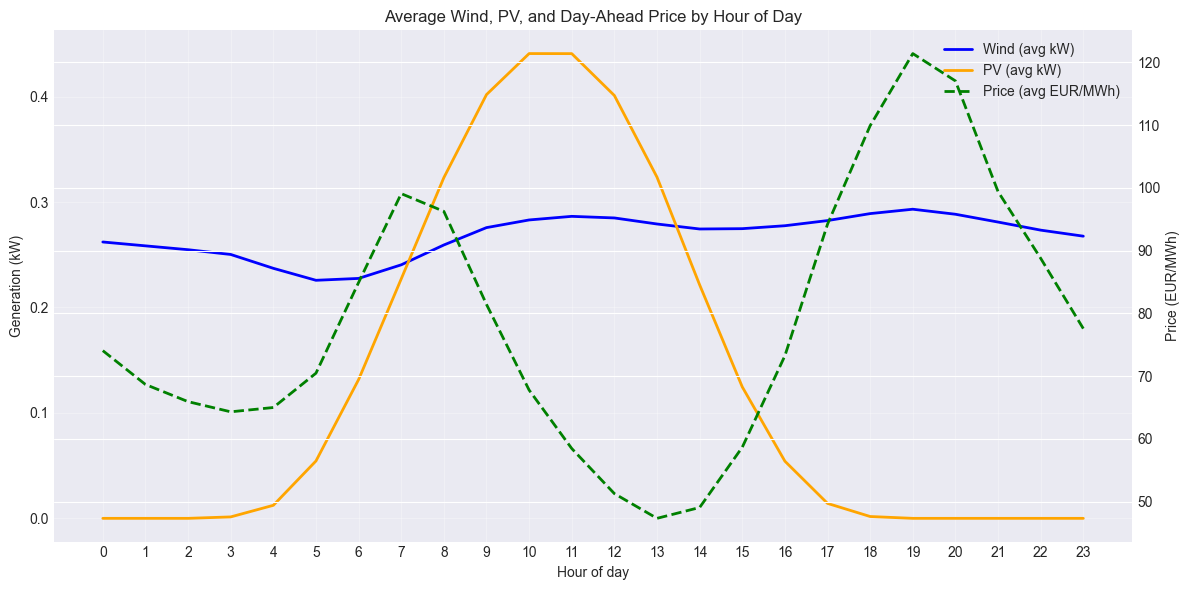

In [13]:
# Hour-of-day averages for wind, PV, and prices
# Note: Wind/PV are 2024, prices are 2024; this is a pattern comparison.
wind_hour = wind_df.groupby(wind_df.index.hour)['wind_kw'].mean()
pv_hour = pv_df.groupby(pv_df.index.hour)['pv_kw'].mean()
price_hour = price_df.groupby(price_df.index.hour)['price_eur_per_mwh'].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(wind_hour.index, wind_hour.values, label='Wind (avg kW)', color='blue', linewidth=2)
ax1.plot(pv_hour.index, pv_hour.values, label='PV (avg kW)', color='orange', linewidth=2)
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Generation (kW)')
ax1.set_xticks(range(0, 24))
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(price_hour.index, price_hour.values, label='Price (avg EUR/MWh)', color='green', linewidth=2, linestyle='--')
ax2.set_ylabel('Price (EUR/MWh)')

lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right')

ax1.set_title('Average Wind, PV, and Day-Ahead Price by Hour of Day')

plt.tight_layout()
plt.show()


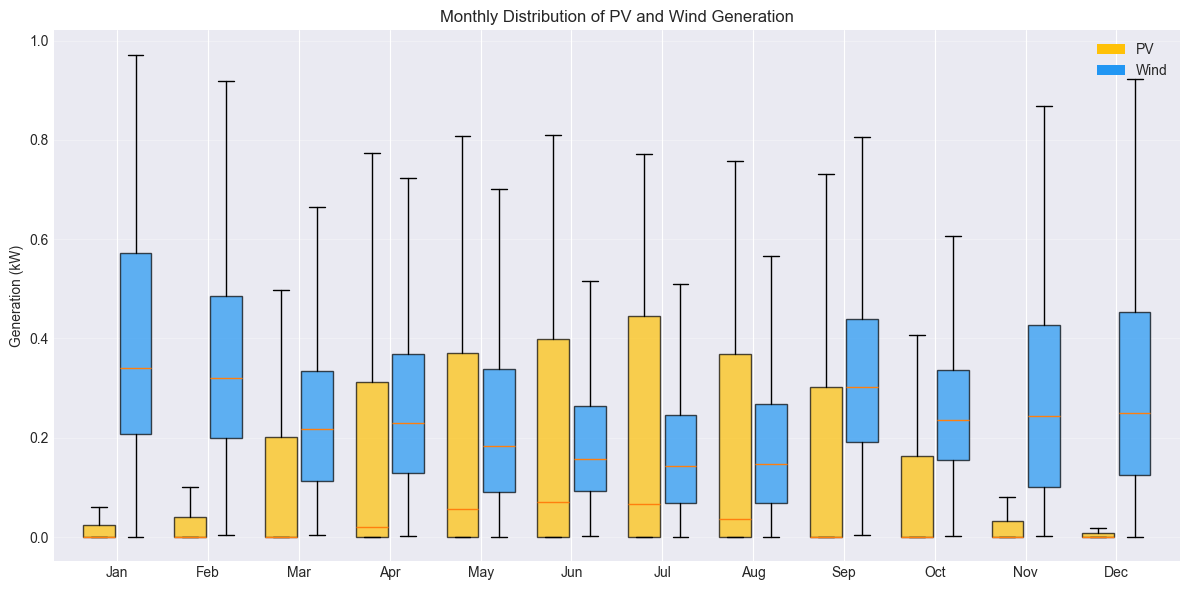

In [14]:
# Monthly distribution of PV and wind generation (per kW)
wind_df['month'] = wind_df.index.month
pv_df['month'] = pv_df.index.month

pv_monthly = [pv_df.loc[pv_df['month'] == m, 'pv_kw'] for m in range(1, 13)]
wind_monthly = [wind_df.loc[wind_df['month'] == m, 'wind_kw'] for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(12, 6))
positions = np.arange(1, 13)
pv_positions = positions - 0.2
wind_positions = positions + 0.2

bp_pv = ax.boxplot(
    pv_monthly,
    positions=pv_positions,
    widths=0.35,
    patch_artist=True,
    showfliers=False,
)
bp_wind = ax.boxplot(
    wind_monthly,
    positions=wind_positions,
    widths=0.35,
    patch_artist=True,
    showfliers=False,
)

for patch in bp_pv['boxes']:
    patch.set_facecolor('#FFC107')
    patch.set_alpha(0.7)
for patch in bp_wind['boxes']:
    patch.set_facecolor('#2196F3')
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_ylabel('Generation (kW)')
ax.set_title('Monthly Distribution of PV and Wind Generation')
ax.grid(True, axis='y', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(facecolor='#FFC107', label='PV'),
        Patch(facecolor='#2196F3', label='Wind'),
    ],
    loc='upper right',
)

plt.tight_layout()
plt.show()


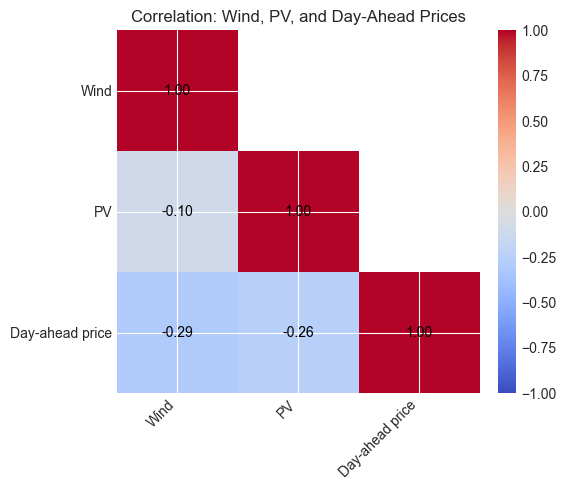

In [15]:
# Correlation between wind, PV, and day-ahead prices
# Note: Wind/PV are 2024; prices are 2024. Align by hour-of-year for a pattern comparison.

price_corr = price_df.copy()
price_corr = price_corr[~((price_corr.index.month == 2) & (price_corr.index.day == 29))]

def hour_of_year(index):
    return (index.dayofyear - 1) * 24 + index.hour

wind_corr = wind_df.assign(hour_of_year=hour_of_year(wind_df.index))
pv_corr = pv_df.assign(hour_of_year=hour_of_year(pv_df.index))
price_corr = price_corr.assign(hour_of_year=hour_of_year(price_corr.index))

wind_series = wind_corr.groupby('hour_of_year')['wind_kw'].mean()
pv_series = pv_corr.groupby('hour_of_year')['pv_kw'].mean()
price_series = price_corr.groupby('hour_of_year')['price_eur_per_mwh'].mean()

corr_df = pd.concat(
    [wind_series, pv_series, price_series],
    axis=1,
    join='inner'
)
corr_df = corr_df.rename(columns={
    'wind_kw': 'Wind',
    'pv_kw': 'PV',
    'price_eur_per_mwh': 'Day-ahead price'
})

corr_matrix = corr_df.corr()

# Mask the upper triangle to reduce redundant labels
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_masked = corr_matrix.mask(mask)

fig, ax = plt.subplots(figsize=(6, 5))
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad(color='white')
im = ax.imshow(corr_masked, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.index)
ax.set_title('Correlation: Wind, PV, and Day-Ahead Prices')

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        if mask[i, j]:
            continue
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [16]:
# Summary statistics table
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

print("\n=== WIND DATA (2024) ===")
print(f"Mean: {wind_df['wind_kw'].mean():.3f} kW")
print(f"Median: {wind_df['wind_kw'].median():.3f} kW")
print(f"Std Dev: {wind_df['wind_kw'].std():.3f} kW")
print(f"Min: {wind_df['wind_kw'].min():.3f} kW")
print(f"Max: {wind_df['wind_kw'].max():.3f} kW")
print(f"Capacity Factor: {wind_df['wind_kw'].mean():.3%}")  # Assuming 1 kW capacity

print("\n=== PV DATA (2024) ===")
print(f"Mean: {pv_df['pv_kw'].mean():.3f} kW")
print(f"Median: {pv_df['pv_kw'].median():.3f} kW")
print(f"Std Dev: {pv_df['pv_kw'].std():.3f} kW")
print(f"Min: {pv_df['pv_kw'].min():.3f} kW")
print(f"Max: {pv_df['pv_kw'].max():.3f} kW")
print(f"Capacity Factor: {pv_df['pv_kw'].mean():.3%}")  # Assuming 1 kW capacity

print("\n=== PRICE DATA (2024) ===")
print(f"Mean: {price_df['price_eur_per_mwh'].mean():.2f} EUR/MWh")
print(f"Median: {price_df['price_eur_per_mwh'].median():.2f} EUR/MWh")
print(f"Std Dev: {price_df['price_eur_per_mwh'].std():.2f} EUR/MWh")
print(f"Min: {price_df['price_eur_per_mwh'].min():.2f} EUR/MWh")
print(f"Max: {price_df['price_eur_per_mwh'].max():.2f} EUR/MWh")

print("\n=== DATA QUALITY CHECKS ===")
print(f"Wind missing values: {wind_df['wind_kw'].isnull().sum()}")
print(f"PV missing values: {pv_df['pv_kw'].isnull().sum()}")
print(f"Price missing values: {price_df['price_eur_per_mwh'].isnull().sum()}")
print(f"Wind negative values: {(wind_df['wind_kw'] < 0).sum()}")
print(f"PV negative values: {(pv_df['pv_kw'] < 0).sum()}")
print(f"Price negative values: {(price_df['price_eur_per_mwh'] < 0).sum()}")

print("\n" + "=" * 80)


SUMMARY STATISTICS

=== WIND DATA (2024) ===
Mean: 0.268 kW
Median: 0.227 kW
Std Dev: 0.201 kW
Min: 0.000 kW
Max: 0.972 kW
Capacity Factor: 26.776%

=== PV DATA (2024) ===
Mean: 0.132 kW
Median: 0.000 kW
Std Dev: 0.212 kW
Min: 0.000 kW
Max: 0.811 kW
Capacity Factor: 13.225%

=== PRICE DATA (2024) ===
Mean: 78.51 EUR/MWh
Median: 79.59 EUR/MWh
Std Dev: 52.73 EUR/MWh
Min: -135.45 EUR/MWh
Max: 936.28 EUR/MWh

=== DATA QUALITY CHECKS ===
Wind missing values: 0
PV missing values: 0
Price missing values: 0
Wind negative values: 0
PV negative values: 0
Price negative values: 457

